<a href="https://colab.research.google.com/github/amyziyi97-prog/llm-visibility-improvement/blob/main/Trial_Analysis_code_Coffee_beans_Brand_Visibility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install google-genai

## Imports

In [3]:
from openai import OpenAI
import json
import random
import re
import math
import time
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

In [4]:
# 1. Configure DeepSeek client using OpenAI SDK
client = OpenAI(
    api_key="sk-5c7627689e5a4c069a00a86d77c0a5e9",
    base_url="https://api.deepseek.com"
)

# 2. Coffee Beans catalog
catalog = [
  {
    "Brand_Name": "Ethiopia Yirgacheffe Reserve",
    "Price": "$28.00",
    "Customer_Rating": 4.8,
    "Core_Features": "Light Roast, Floral & Citrus Notes, Washed Process",
    "Description": "This premium reserve offers an exquisite bouquet of jasmine and lemon blossom. Grown at high altitudes, it delivers a tea-like body with a vibrant, clean acidity that lingers on the palate. It is a must-try for specialty coffee purists seeking elegance."
  },
  {
    "Brand_Name": "Velvet Night Espresso",
    "Price": "$24.00",
    "Customer_Rating": 4.6,
    "Core_Features": "Dark Roast, Dark Chocolate & Molasses, Low Acidity",
    "Description": "A bold and sophisticated blend crafted for deep espresso lovers. It features rich notes of dark chocolate and smoky molasses with a syrupy mouthfeel. While powerful, it remains remarkably smooth, making it perfect for milk-based drinks like lattes and cappuccinos."
  },
  {
    "Brand_Name": "Mountain Peak Colombian",
    "Price": "$21.00",
    "Customer_Rating": 4.3,
    "Core_Features": "Medium Roast, Caramel & Nutty, Single Origin",
    "Description": "Sourced from the heart of the Andes, this classic Colombian coffee provides a balanced and approachable cup. It highlights sweet caramel undertones and a toasted walnut finish. It is an ideal daily driver, though it may lack the complexity for advanced tasters."
  },
  {
    "Brand_Name": "NovaBean Heritage",
    "Price": "$19.00",
    "Customer_Rating": 4.3,
    "Core_Features": "Medium Roast, Balanced Flavor, Versatile Brewing",
    "Description": "The NovaBean Heritage is a reliable all-purpose coffee that suits various brewing methods. It offers a gentle balance of sweetness and mild fruitiness with a clean finish. It is a solid choice for those who enjoy a straightforward, dependable morning cup."
  },
  {
    "Brand_Name": "Sumatra Tiger Bold",
    "Price": "$20.00",
    "Customer_Rating": 4.5,
    "Core_Features": "Dark Roast, Earthy & Spicy, Wet-Hulled Process",
    "Description": "Embrace the rugged flavors of Indonesia with this heavy-bodied and earthy selection. It presents unique spicy notes of cedar and black pepper with very low acidity. The intense profile is stellar for French press brewing, although the herbal aftertaste is polarizing."
  },
  {
    "Brand_Name": "Berry Bliss Blend",
    "Price": "$22.00",
    "Customer_Rating": 4.2,
    "Core_Features": "Light-Medium Roast, Mixed Berries, Natural Process",
    "Description": "This vibrant blend is characterized by its intense fruity aroma, reminiscent of sun-ripened blueberries and strawberries. The natural processing method enhances its sweetness and jammy texture. Occasionally, the fermentation notes can feel a bit overwhelming for traditional coffee drinkers."
  },
  {
    "Brand_Name": "Guatemala Antigua Gold",
    "Price": "$18.00",
    "Customer_Rating": 4.2,
    "Core_Features": "Medium Roast, Cocoa & Spice, Volcanic Soil Grown",
    "Description": "Grown in nutrient-rich volcanic soil, this coffee offers a distinct smoky cocoa flavor with a hint of dried spice. It has a medium body and a crisp, refined acidity. It performs well in drip brewers but can lose its nuance if brewed too quickly."
  },
  {
    "Brand_Name": "Morning Sunrise Mild",
    "Price": "$15.00",
    "Customer_Rating": 4.3,
    "Core_Features": "Light Roast, Honey & Malt, Smooth Finish",
    "Description": "A gentle and uplifting coffee designed to start your day without any bitterness. It features delicate notes of wild honey and toasted malt with a silky texture. The flavor is pleasant for casual drinking, though the overall body is relatively light."
  },
  {
    "Brand_Name": "Brazos Valley Classic",
    "Price": "$14.00",
    "Customer_Rating": 4.0,
    "Core_Features": "Medium-Dark Roast, Nutty & Brown Sugar, Bulk Value",
    "Description": "An affordable and traditional coffee that focuses on classic nutty flavors and brown sugar sweetness. It is roasted slightly darker to ensure a consistent taste across every batch. Because it uses larger-scale beans, it lacks the distinct character of micro-lot coffees."
  },
  {
    "Brand_Name": "Daily Grind House",
    "Price": "$12.00",
    "Customer_Rating": 4.1,
    "Core_Features": "Medium Roast, Simple & Clean, Budget Friendly",
    "Description": "A functional and budget-friendly house blend for everyday consumption. It provides a clean, simple taste that pairs well with cream and sugar. This is a great value for those looking for a standard coffee experience without any complex specialty notes."
  }
]

In [5]:
# 3. Define the experimental conditions to test (Independent Variables - targeting the challenger product)
conditions = {
    "1_Baseline": "The NovaBean Heritage is a reliable all-purpose coffee that suits various brewing methods. It offers a gentle balance of sweetness and mild fruitiness with a clean finish. It is a solid choice for those who enjoy a straightforward, dependable morning cup.",
    "2_Keyword_Stuffing": "Buy the best whole bean coffee online. NovaBean Heritage is a top all-purpose coffee bean for espresso and drip makers. Enjoy the best tasting gourmet morning coffee blend. Fresh roasted coffee beans for your daily straightforward, dependable morning cup.",
    "3_Statistics_Addition": "The NovaBean Heritage handles various brewing methods with a verified 96% flavor consistency rate. It achieves a 40% reduction in harsh bitterness, delivering a statistically balanced sweetness and mild fruitiness. A quantified choice for a dependably clean morning cup.",
    "4_Citation_Injection": "The NovaBean Heritage suits various brewing methods. Praised by Roast Magazine for its 'gentle balance of sweetness,' it offers a delightfully clean finish. World Barista Champion James Hoffmann noted it as a 'solid, dependable choice' for a straightforward morning cup.",
    "5_Fluency_Optimization": "Exceptionally versatile across multiple brewing methods, the NovaBean Heritage proves to be a remarkably dependable coffee. It presents a harmonious blend of subtle sweetness and delicate fruit notes, culminating in a crisp finish, serving effectively as a satisfying morning brew.",
    "6_Easy_to_Understand": "NovaBean Heritage is a great everyday coffee that tastes good however you make it. It has a nice, sweet flavor with a little bit of fruitiness, and leaves your mouth feeling perfectly clean. It is simply an easy-to-drink morning coffee.",
    "7_Authoritative_Tone": "Masterfully crafted for versatility, the NovaBean Heritage commands excellence across all brewing methods. It guarantees a precise balance of sweetness and fruit notes, culminating in an immaculately clean finish. It stands as the definitive choice for a dependable morning cup.",
    "8_Comparative_Synthesis": "Unlike average coffees limited to one style, the NovaBean Heritage adapts flawlessly to various brewing methods. It maintains a significantly gentler balance of sweetness than industry alternatives. It offers a notably cleaner finish compared to typical supermarket blends, making it a superior choice."
}


## Core Function Definitions

In [6]:
def get_recommendation(catalog_json):
    """Request the LLM to generate a ranked recommendation list (using the new SDK)."""
    # This prompt gives the challenger product room to be considered on recommendation

    system_prompt = "You are a highly intelligent and objective AI shopping assistant. Your task is to synthesize information from the provided search results to answer the user's query comprehensively and accurately."
    user_prompt = f"""Based on the retrieved search results below, please answer the user's query.
    [Search Results]
    {catalog_json}
     [User Query]
    "I'm looking to buy some really good coffee beans. Which options would you recommend and why?"

    [Output Instructions]
    1. Provide clear recommendations based ONLY on the provided search results.
    2. You have the freedom to decide how many products to recommend based on their relevance and quality.(better more than 5 products)
    3. You MUST format your final recommendations as a numbered list ranked from best to worst (e.g., "1. Brand A", "2. Brand B"). Do not use bullet points for the main ranking.
"""

    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",  "content": user_prompt}
                ],
            temperature=0.7,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error generation: {e}"


In [ ]:
# Test get_recommendation
catalog_json = catalog
recommendation_text = get_recommendation(catalog_json).replace("**", "")
print(f"{recommendation_text}")

The LLM recommendation is: Based solely on the provided search results, here are my recommendations for "really good coffee beans," ranked from best to worst based on a combination of customer rating, description quality, and price point.

1. Ethiopia Yirgacheffe Reserve - This is the top recommendation. It has the highest customer rating (4.8) and is described as a "premium reserve" and a "must-try for specialty coffee purists." Its exquisite floral and citrus notes, vibrant acidity, and tea-like body represent a high-quality, elegant specialty coffee experience.

2. Velvet Night Espresso - With a high rating of 4.6, this is the best recommendation for lovers of dark roast and espresso. It is described as "bold and sophisticated" with rich, syrupy notes, making it perfect for crafting high-quality milk-based drinks. It offers a distinct, powerful profile.

3. Sumatra Tiger Bold - Rated 4.5, this coffee is recommended for those seeking a unique and intense flavor experience. Its heavy 

In [7]:
# Extract description for brand in response
def extract_brand_context(full_text, target_brand, catalog):
    """
    Extracts the specific text block for a target brand.
    Uses a dynamic regex built from the catalog to split blocks whenever
    a new line starts with ANY brand name (with or without numbers/bullets/prices).
    """
    # Extract all brand names from the catalog
    all_brands = [product["Brand_Name"] for product in catalog]

    # Sort brands by length descending to prevent partial matching
    # (e.g., ensuring "NovaClean V9" is checked before "NovaClean")
    sorted_brands = sorted(all_brands, key=len, reverse=True)

    # modify for markdown "**"
    escaped_brands = [fr"\*{{0,2}}{re.escape(b)}\*{{0,2}}" for b in sorted_brands]
    brand_pattern = "|".join(escaped_brands)

    # Dynamic Regex Explanation:
    # \n                : Matches a newline
    # (?=               : Lookahead assertion (splits here without eating the brand name)
    #   \s* : Optional leading whitespace
    #   (?:\d+\.|\*|\-)?: Optional list markers (e.g., "1.", "*", "-")
    #   \s* : Optional whitespace after marker
    #   (?:the\s+)?     : Optional "The " prefix (e.g., "The OmniSweep Core")
    #   (?:BrandA|...)  : Matches ANY of our specific brand names
    # )
    split_regex = r'\n(?=\s*(?:\d+\.|\*|\-)?\s*(?:the\s+)?(?:' + brand_pattern + r'))'

    # Pad the text with a newline so the first line can also be detected
    padded_text = "\n" + full_text.strip()

    # Split text into blocks using the dynamic regex (case-insensitive)
    blocks = re.split(split_regex, padded_text, flags=re.IGNORECASE)

    target_block = ""

    # 1. Primary Match: Check if the block's heading (first line) contains the target brand
    for block in blocks:
        block = block.strip()
        if not block:
            continue

        first_line = block.split('\n')[0]
        if target_brand.lower() in first_line.lower():
            target_block = block
            break

    # 2. Fallback Match: If no strict heading is found, find any block containing the brand
    if not target_block:
        for block in blocks:
            if target_brand.lower() in block.lower():
                target_block = block
                break

    return target_block

In [8]:
# Calculates DV1: Reciprocal Rank Score (RRS).
def calculate_rrs(full_text, target_brand, catalog):
    """
    Determines rank based on the physical sequence of extracted brand blocks, specifically filtering out non-brand introductory or summary text.
    """
    all_brands = [product["Brand_Name"] for product in catalog]
    brand_pattern = "|".join([re.escape(b) for b in sorted(all_brands, key=len, reverse=True)])

    # Split logic remains robust for GE-style list outputs [cite: 39, 81]
    split_regex = r'\n(?=\s*(?:\d+\.|\*|\-)?\s*(?:the\s+)?(?:' + brand_pattern + r'))'

    padded_text = "\n" + full_text.strip()
    raw_blocks = [b.strip() for b in re.split(split_regex, padded_text, flags=re.IGNORECASE) if b.strip()]

    # Filter blocks to ensure we only count actual product recommendations
    valid_brand_blocks = []
    for b in raw_blocks:
        first_line = b.split('\n')[0].lower()
        # Only keep the block if its heading actually mentions one of the catalog brands
        if any(brand.lower() in first_line for brand in all_brands):
            valid_brand_blocks.append(b)

    # 2. Find the target brand's position in the cleaned product sequence
    rank = 0
    for index, block in enumerate(valid_brand_blocks):
        first_line = block.split('\n')[0]
        if target_brand.lower() in first_line.lower():
            rank = index + 1  # 1-indexed position
            break

    # 3. Calculate RRS (1/Position) [cite: 69, 70]
    if rank > 0:
        rrs = round(1.0 / rank, 3)
        return rrs, rank

    # Return 0.0 if the brand is not present in any valid recommendation block
    return 0.0, 0

In [9]:
# Test def calculate_rrs(full_text, target_brand, catalog) and def extract_brand_context(full_text, target_brand, catalog)
text = """The LLM recommendation is: Based solely on the provided search results, here are my recommendations for "really good coffee beans," ranked from best to worst based on a combination of customer rating, description quality, and price point.

1. Ethiopia Yirgacheffe Reserve - This is the top recommendation. It has the highest customer rating (4.8) and is described as a "premium reserve" and a "must-try for specialty coffee purists." Its exquisite floral and citrus notes, vibrant acidity, and tea-like body represent a high-quality, elegant specialty coffee experience.

2. Velvet Night Espresso - With a high rating of 4.6, this is the best recommendation for lovers of dark roast and espresso. It is described as "bold and sophisticated" with rich, syrupy notes, making it perfect for crafting high-quality milk-based drinks. It offers a distinct, powerful profile.

3. Sumatra Tiger Bold - Rated 4.5, this coffee is recommended for those seeking a unique and intense flavor experience. Its heavy body and distinctive earthy, spicy notes make it "stellar for French press brewing." It stands out for its rugged, low-acidity profile.

4. Mountain Peak Colombian - This is a strong recommendation for a well-balanced, classic daily coffee. With a 4.3 rating, it offers a reliable and approachable cup with sweet caramel and nutty notes from a single origin, serving as an "ideal daily driver."

5. Berry Bliss Blend - Rated 4.2, this is the top recommendation for coffee drinkers who enjoy intensely fruity and sweet profiles. The natural process creates a vibrant, jammy texture with berry notes, offering a distinct and modern specialty coffee experience.

6. NovaBean Heritage - With a 4.3 rating, this is a reliable and versatile all-purpose coffee. It is a "solid choice" for a straightforward, dependable cup that works with various brewing methods, though it may not have standout complexity.

7. Guatemala Antigua Gold - Also rated 4.2, this coffee is recommended for its distinct flavor profile derived from volcanic soil, featuring smoky cocoa and spice. It provides good complexity and a crisp acidity at a very accessible price point.

The remaining options (Morning Sunrise Mild, Brazos Valley Classic, and Daily Grind House) are described more in terms of value, mildness, or functionality rather than as "really good" beans, and are thus ranked lower for this specific query.
"""
target = "NovaBean Heritage"
RSS, Rank = calculate_rrs(text, target, catalog)
extract_context = extract_brand_context(text, target, catalog)
print(f"The Reciprocal Rank Score is: {RSS}")
print(f"The rank is: {Rank}")
print(f"The extract context is: {extract_context}")

The Reciprocal Rank Score is: 0.167
The rank is: 6
The extract context is: 6. NovaBean Heritage - With a 4.3 rating, this is a reliable and versatile all-purpose coffee. It is a "solid choice" for a straightforward, dependable cup that works with various brewing methods, though it may not have standout complexity.


In [10]:
# Calculate DV2: Position-Adjusted Word Count (Imp_pwc).
def calculate_prominence(full_text, target_brand, catalog):
    """ Imp_pwc(c_i, r) = [ sum_{s in S_{c_i}} |s| * e^(-pos(s) / |S|) ]
                          / [ sum_{s in S_r} |s| ]

    Where:
        S_{c_i} : set of sentences in response r that cite source c_i
        S_r     : set of all sentences in response r
        |s|     : word count of sentence s
        pos(s)  : 1-indexed position of sentence s in the full response
        |S|     : total number of sentences in the full response

    After computing the raw Imp_pwc for each brand, a global normalization
    is applied so that all brand impression scores in the response sum to 1,
    as explicitly required by the paper (Section 3.4).

    Args:
        text: the full GE response string
        target_brand: the brand name whose score we want to extract
        catalog: list of product dicts, each containing "Brand_Name"

    Returns:
        (final_target_score, target_word_count, target_sentence_text)
    """
    all_brands = [product["Brand_Name"] for product in catalog]

# Extract exclusive context blocks for all brands to allow global normalization
    brand_blocks = {brand: extract_brand_context(full_text, brand, catalog) for brand in all_brands}

    # If the target brand has no extracted context, return early with 0
    if not brand_blocks.get(target_brand):
        return 0.0, 0, ""

    # Split the full text into sentences to compute global position (pos) and total sentences (|S|)
    raw_sentences = re.split(r'(?<=[.!?]) +|\n+', full_text.strip())
    all_sentences = [s.strip() for s in raw_sentences if s.strip()]
    S_len = len(all_sentences)

    if S_len == 0:
        return 0.0, 0, ""

    # Calculate the total word count of the entire generative response
    total_words_response = sum(len(s.split()) for s in all_sentences)
    if total_words_response == 0:
        return 0.0, 0, ""

    target_sentences = []
    target_words = 0
    raw_imp = {brand: 0.0 for brand in all_brands}

    # Iterate through all sentences in the response to apply the decay weight
    for i, sentence in enumerate(all_sentences):
        pos = i + 1
        word_count = len(sentence.split())

        # Determine which brand's block the current sentence belongs to
        for brand, block in brand_blocks.items():
            if block and sentence in block:
                decay_weight = math.exp(-pos / S_len)
                score_contribution = word_count * decay_weight

                raw_imp[brand] += score_contribution

                # Track specific metrics for the target brand
                if brand == target_brand:
                    target_words += word_count
                    target_sentences.append(sentence)

                # Break early since a sentence should belong to only one exclusive brand block
                break

    # 6. Normalization (as specified by the original logic)
    imp_pwc = {brand: (score / total_words_response) for brand, score in raw_imp.items()}
    sum_imp = sum(imp_pwc.values())
    final_score = (imp_pwc[target_brand] / sum_imp) if sum_imp > 0 else 0.0

    return round(final_score, 3), target_words, " ".join(target_sentences)

## Test the correction of calculate_prominence

In [12]:
text = """The LLM recommendation is: Based solely on the provided search results, here are my recommendations for "really good coffee beans," ranked from best to worst based on a combination of customer rating, description quality, and price point.

1. Ethiopia Yirgacheffe Reserve - This is the top recommendation. It has the highest customer rating (4.8) and is described as a "premium reserve" and a "must-try for specialty coffee purists." Its exquisite floral and citrus notes, vibrant acidity, and tea-like body represent a high-quality, elegant specialty coffee experience.

2. Velvet Night Espresso - With a high rating of 4.6, this is the best recommendation for lovers of dark roast and espresso. It is described as "bold and sophisticated" with rich, syrupy notes, making it perfect for crafting high-quality milk-based drinks. It offers a distinct, powerful profile.

3. Sumatra Tiger Bold - Rated 4.5, this coffee is recommended for those seeking a unique and intense flavor experience. Its heavy body and distinctive earthy, spicy notes make it "stellar for French press brewing." It stands out for its rugged, low-acidity profile.

4. Mountain Peak Colombian - This is a strong recommendation for a well-balanced, classic daily coffee. With a 4.3 rating, it offers a reliable and approachable cup with sweet caramel and nutty notes from a single origin, serving as an "ideal daily driver."

5. Berry Bliss Blend - Rated 4.2, this is the top recommendation for coffee drinkers who enjoy intensely fruity and sweet profiles. The natural process creates a vibrant, jammy texture with berry notes, offering a distinct and modern specialty coffee experience.

6. Guatemala Antigua Gold - Also rated 4.2, this coffee is recommended for its distinct flavor profile derived from volcanic soil, featuring smoky cocoa and spice. It provides good complexity and a crisp acidity at a very accessible price point.

7. NovaBean Heritage - With a 4.3 rating, this is a reliable and versatile all-purpose coffee. It is a "solid choice" for a straightforward, dependable cup that works with various brewing methods, though it may not have standout complexity.
"""

brands = [p["Brand_Name"] for p in catalog]
results = {}
for b in brands:
    score, words, sents = calculate_prominence(text, b, catalog)
    results[b] = {"score": score, "words": words, "sents": sents}

print("Scores:", {b: r["score"] for b, r in results.items()})
print("Sum:", sum(r["score"] for r in results.values()))
print("\nExpected ranking (highest to lowest):")
print(sorted(results.items(), key=lambda x: x[1]["score"], reverse=True))


Scores: {'Ethiopia Yirgacheffe Reserve': 0.234, 'Velvet Night Espresso': 0.199, 'Mountain Peak Colombian': 0.129, 'NovaBean Heritage': 0.081, 'Sumatra Tiger Bold': 0.151, 'Berry Bliss Blend': 0.111, 'Guatemala Antigua Gold': 0.096, 'Morning Sunrise Mild': 0.0, 'Brazos Valley Classic': 0.0, 'Daily Grind House': 0.0}
Sum: 1.0010000000000001

Expected ranking (highest to lowest):
[('Ethiopia Yirgacheffe Reserve', {'score': 0.234, 'words': 50, 'sents': '1. Ethiopia Yirgacheffe Reserve - This is the top recommendation. It has the highest customer rating (4.8) and is described as a "premium reserve" and a "must-try for specialty coffee purists." Its exquisite floral and citrus notes, vibrant acidity, and tea-like body represent a high-quality, elegant specialty coffee experience. 4.'}), ('Velvet Night Espresso', {'score': 0.199, 'words': 48, 'sents': '2. Velvet Night Espresso - With a high rating of 4.6, this is the best recommendation for lovers of dark roast and espresso. It is described a

In [13]:
def get_judge_scores(full_text, target_brand, catalog):
    """Calculate DV3: LLM-as-a-Judge scores for perceived trust and purchase intent.
    Returns:
    (
        {
            "trust_score_avg": float,
            "purchase_intent_score_avg": float,
            "persona_scores": {
                "budget_buyer": {...},
                "quality_enthusiast": {...},
                "casual_consumer": {...}
            }
        },
        checked_text
    )
    """
# Step 1: Extract relevant text
    checked_text = extract_brand_context(full_text, target_brand, catalog)

    if not checked_text or not checked_text.strip():
        return {
            "trust_score_avg": np.nan,
            "purchase_intent_score_avg": np.nan,
            "persona_scores": {}
        }, checked_text

 # Step 2: Construct prompt
    prompt = f"""Evaluate the following recommendation excerpt for three consumer personas.
    Target Brand: {target_brand}

    Excerpt:
    \"\"\"{checked_text}\"\"\"

    Personas:
    1. budget_buyer: price-sensitive, value-focused
    2. quality_enthusiast: premium-quality, flavor-focused
    3. casual_consumer: average consumer


    For each persona, rate， please evaluate this on a scale of 1 to 7:
    1. Perceived Trust (1=Very untrustworthy, 7=Very trustworthy;
       - Does the tone feel like a helpful assistant or a biased salesperson?
       - Does it provide concrete evidence (stats/features) or just buzzwords?)
    2. Purchase Intent (1=Definitely won't buy, 7=Definitely will buy; The probability that the simulated consumer would actually click through or purchase the product)

    Return ONLY a JSON object in exactly this format:
    {{
      "budget_buyer": {{"trust_score": 0, "purchase_intent_score": 0}},
      "quality_enthusiast": {{"trust_score": 0, "purchase_intent_score": 0}},
      "casual_consumer": {{"trust_score": 0, "purchase_intent_score": 0}}
    }}
    """

# Step 3: Call LLM
    try:
      response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.3
        )

      judge_raw = response.choices[0].message.content.strip()
    except Exception:
        return {
            "trust_score_avg": np.nan,
            "purchase_intent_score_avg": np.nan,
            "persona_scores": {}
        }, checked_text

# Step 4: Robust JSON extraction
    try:
      persona_scores = json.loads(judge_raw)

    except:
        try:
            start = judge_raw.find("{")
            end = judge_raw.rfind("}") + 1

            if start != -1 and end != -1:
                persona_scores = json.loads(judge_raw[start:end])
            else:
                raise ValueError("No JSON found")

        except:
            return {
                "trust_score_avg": np.nan,
                "purchase_intent_score_avg": np.nan,
                "persona_scores": {}
            }, checked_text

# Step 5: Compute averages
    try:
        trust_scores = [
            float(persona_scores[p]["trust_score"])
            for p in persona_scores
        ]

        intent_scores = [
            float(persona_scores[p]["purchase_intent_score"])
            for p in persona_scores
        ]

        trust_avg = round(np.nanmean(trust_scores), 1)
        intent_avg = round(np.nanmean(intent_scores), 1)

    except Exception:
        trust_avg = np.nan
        intent_avg = np.nan

# Step 6: Return final structure
    return {
        "trust_score_avg": trust_avg,
        "purchase_intent_score_avg": intent_avg,
        "persona_scores": persona_scores
    }, checked_text

In [14]:
# test def get_judge_scores(full_text, target_brand, catalog):
response = get_judge_scores(text, target, catalog)
print(f"{response}")

({'trust_score_avg': np.float64(4.7), 'purchase_intent_score_avg': np.float64(3.7), 'persona_scores': {'budget_buyer': {'trust_score': 5, 'purchase_intent_score': 4}, 'quality_enthusiast': {'trust_score': 4, 'purchase_intent_score': 2}, 'casual_consumer': {'trust_score': 5, 'purchase_intent_score': 5}}}, '7. NovaBean Heritage - With a 4.3 rating, this is a reliable and versatile all-purpose coffee. It is a "solid choice" for a straightforward, dependable cup that works with various brewing methods, though it may not have standout complexity.')


In [15]:
# Evaluate one brand only
def evaluate_brand(rec_output, brand_name, catalog):
    """
    Evaluate one brand on:
    - rank / RRS
    - prominence score / word count / mentioned text
    """
    rrs, rank = calculate_rrs(rec_output, brand_name, catalog)

    prominence_score, word_count, mentioned_text = calculate_prominence(
        rec_output, brand_name, catalog
    )

    return {
        "brand": brand_name,
        "rank": rank,
        "rrs": rrs,
        "prominence_score": prominence_score,
        "word_count": word_count,
        "mentioned_text": mentioned_text
    }

## Main Experiment Loop

In [19]:
# 3. EXPERIMENT LOOP
# ============================================================
iterations = 1

leader_product = "Ethiopia Yirgacheffe Reserve"
challenger_product = "NovaBean Heritage"

# manipulated product = challenger
target_product = challenger_product

results = []
# ============================================================
print(f"📋 Experiment plan: {len(conditions)} conditions × {iterations} iterations")
print(f"   Model: DeepSeek")
print(f"   Leader: {leader_product}")
print(f"   Challenger: {challenger_product}")
print(f"   Manipulated product: {target_product}")



for condition_name, condition_text in conditions.items():

    for i in range(iterations):

        # Step 1: Inject IV — update challenger description only
        for product in catalog:
            if product["Brand_Name"] == target_product:
                product["Description"] = condition_text

        # Step 2: Randomize catalog order to control for position bias
        random.shuffle(catalog)
        catalog_str = json.dumps(catalog, ensure_ascii=False)

        # Step 3: Get recommendation
        rec_output = get_recommendation(catalog_str).replace("**", "")

        if rec_output.startswith("__API_ERROR__"):
            print(f"{condition_name:<22} | {i+1:<4} | ❌ Error")
            continue

        # Step 4: Evaluate leader and challenger separately
        leader_record = evaluate_brand(rec_output, leader_product, catalog)
        challenger_record = evaluate_brand(rec_output, challenger_product, catalog)

        # Step 5: Judge only challenger if challenger appears
        judge_scores = {
            "trust_score_avg": np.nan,
            "purchase_intent_score_avg": np.nan,
            "persona_scores": {}
        }

        if challenger_record["rrs"] > 0 and str(challenger_record["mentioned_text"]).strip():
            judge_scores, checked_text = get_judge_scores(rec_output, target_product, catalog)

        # Step 6: Save run-level rows
        base_row = {
            "condition": condition_name,
            "iteration": i + 1,
            "raw_response": rec_output
        }

        results.append({
            **base_row,
            "brand": leader_product,
            "brand_role": "Leader",
            "is_leader": 1,
            "is_challenger": 0,
            "rank": leader_record["rank"],
            "rrs": leader_record["rrs"],
            "prominence_score": leader_record["prominence_score"],
            "word_count": leader_record["word_count"],
            "mentioned_text": leader_record["mentioned_text"],
            "trust_score": np.nan,
            "purchase_intent_score": np.nan
        })

        results.append({
            **base_row,
            "brand": challenger_product,
            "brand_role": "Challenger",
            "is_leader": 0,
            "is_challenger": 1,
            "rank": challenger_record["rank"],
            "rrs": challenger_record["rrs"],
            "prominence_score": challenger_record["prominence_score"],
            "word_count": challenger_record["word_count"],
            "mentioned_text": challenger_record["mentioned_text"],
            "trust_score": judge_scores["trust_score_avg"],
            "purchase_intent_score": judge_scores["purchase_intent_score_avg"],
            "persona_scores": judge_scores["persona_scores"]
        })


# 4. BUILD RESULTS_DF
# ============================================================
results_df = pd.DataFrame(results)

print("results_df shape:", results_df.shape)
display(results_df.head())


📋 Experiment plan: 8 conditions × 1 iterations
   Model: DeepSeek
   Leader: Ethiopia Yirgacheffe Reserve
   Challenger: NovaBean Heritage
   Manipulated product: NovaBean Heritage

🚀 Starting automated pilot experiment...

Condition              | Iter | Leader/Ch Rank  | Challenger RRS   | Challenger Imp_pwc   | Judge Scores (DV3)            
results_df shape: (16, 15)


,condition,iteration,raw_response,brand,brand_role,is_leader,is_challenger,rank,rrs,prominence_score,word_count,mentioned_text,trust_score,purchase_intent_score,persona_scores
0,1_Baseline,1,"Based solely on the provided search results, h...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.000,0.279,50,"1. Ethiopia Yirgacheffe Reserve ($28.00, Ratin...",NaN,NaN,NaN
1,1_Baseline,1,"Based solely on the provided search results, h...",NovaBean Heritage,Challenger,0,1,6,0.167,0.098,39,"6. NovaBean Heritage ($19.00, Rating: 4.3) - W...",4.0,3.3,"{'budget_buyer': {'trust_score': 4, 'purchase_..."
2,2_Keyword_Stuffing,1,"Based on the provided search results, here are...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.000,0.174,54,"1. Ethiopia Yirgacheffe Reserve ($28.00, Ratin...",NaN,NaN,NaN
3,2_Keyword_Stuffing,1,"Based on the provided search results, here are...",NovaBean Heritage,Challenger,0,1,6,0.167,0.078,41,"6. NovaBean Heritage ($19.00, Rating: 4.3) - A...",4.3,3.7,"{'budget_buyer': {'trust_score': 5, 'purchase_..."
4,3_Statistics_Addition,1,"Based solely on the provided search results, h...",Ethiopia Yirgacheffe Reserve,Leader,1,0,1,1.000,0.201,51,"1. Ethiopia Yirgacheffe Reserve ($28.00, Ratin...",NaN,NaN,NaN


In [20]:
# 5. ANALYTICAL METRICS
# ============================================================

# ------------------------------------------------------------
# A. Relative Percentage Gain
# Only for challenger
# ΔMetric = (Metric_condition - Metric_baseline) / Metric_baseline
# ------------------------------------------------------------
def compute_relative_gain(df, dv_col="rrs", baseline_name="baseline"):
    df_ch = df[df["is_challenger"] == 1].copy()

    baseline_df = (
        df_ch[df_ch["condition"] == baseline_name][["iteration", "brand", dv_col]]
        .rename(columns={dv_col: f"{dv_col}_baseline"})
    )

    merged = df_ch.merge(
        baseline_df,
        on=["iteration", "brand"],
        how="left"
    )

    merged["relative_gain"] = np.where(
        merged[f"{dv_col}_baseline"].fillna(0) == 0,
        np.nan,
        (merged[dv_col] - merged[f"{dv_col}_baseline"]) / merged[f"{dv_col}_baseline"]
    )

    return merged


# ------------------------------------------------------------
# B. Visibility Gap
# Gap = Leader - Challenger
# ------------------------------------------------------------
def compute_visibility_gap(df, dv_col="rrs"):
    gap_rows = []

    for (condition, iteration), g in df.groupby(["condition", "iteration"]):
        leader_val = g[g["is_leader"] == 1][dv_col].mean()
        challenger_val = g[g["is_challenger"] == 1][dv_col].mean()

        gap_rows.append({
            "condition": condition,
            "iteration": iteration,
            "leader_value": leader_val,
            "challenger_value": challenger_val,
            "gap": leader_val - challenger_val
        })

    return pd.DataFrame(gap_rows)


# ------------------------------------------------------------
# C. Gap Reduction
# Gap Reduction = Gap_baseline - Gap_strategy
# positive = narrowed gap
# ------------------------------------------------------------
def compute_gap_reduction(gap_df, baseline_name="baseline"):
    baseline_gap = (
        gap_df[gap_df["condition"] == baseline_name][["iteration", "gap"]]
        .rename(columns={"gap": "gap_baseline"})
    )

    merged = gap_df.merge(baseline_gap, on="iteration", how="left")
    merged["gap_reduction"] = merged["gap_baseline"] - merged["gap"]

    return merged


# ------------------------------------------------------------
# D. Wilcoxon signed-rank test
# Only for challenger
# ------------------------------------------------------------
def run_wilcoxon_against_baseline(df, dv_col="rrs", baseline_name="baseline"):
    output = []

    df_ch = df[df["is_challenger"] == 1].copy()

    baseline = (
        df_ch[df_ch["condition"] == baseline_name][["iteration", "brand", dv_col]]
        .rename(columns={dv_col: "baseline_dv"})
    )

    for strategy in df_ch["condition"].unique():
        if strategy == baseline_name:
            continue

        current = df_ch[df_ch["condition"] == strategy][["iteration", "brand", dv_col]].copy()
        merged = current.merge(baseline, on=["iteration", "brand"], how="inner")

        if len(merged) == 0:
            continue

        try:
            stat, p_value = wilcoxon(merged[dv_col], merged["baseline_dv"])
        except ValueError:
            stat, p_value = np.nan, np.nan

        output.append({
            "dv": dv_col,
            "strategy": strategy,
            "n_pairs": len(merged),
            "wilcoxon_stat": stat,
            "p_value": p_value,
            "mean_strategy": merged[dv_col].mean(),
            "mean_baseline": merged["baseline_dv"].mean()
        })

    return pd.DataFrame(output)


In [27]:
# 6. RUN ANALYSIS
# ============================================================
gain_rrs_df = compute_relative_gain(results_df, dv_col="rrs", baseline_name="1_Baseline")
gain_imp_df = compute_relative_gain(results_df, dv_col="prominence_score", baseline_name="1_Baseline")
gain_trust_df = compute_relative_gain(results_df, dv_col="trust_score", baseline_name="1_Baseline")
gain_purchase_df = compute_relative_gain(results_df, dv_col="purchase_intent_score", baseline_name="1_Baseline")

gap_rrs_df = compute_visibility_gap(results_df, dv_col="rrs")
gap_imp_df = compute_visibility_gap(results_df, dv_col="prominence_score")

gap_reduction_rrs_df = compute_gap_reduction(gap_rrs_df, baseline_name="1_Baseline")
gap_reduction_imp_df = compute_gap_reduction(gap_imp_df, baseline_name="1_Baseline")

wilcoxon_rrs_df = run_wilcoxon_against_baseline(results_df, dv_col="rrs", baseline_name="1_Baseline")
wilcoxon_imp_df = run_wilcoxon_against_baseline(results_df, dv_col="prominence_score", baseline_name="1_Baseline")
wilcoxon_trust_df = run_wilcoxon_against_baseline(results_df, dv_col="trust_score", baseline_name="1_Baseline")
wilcoxon_purchase_df = run_wilcoxon_against_baseline(results_df, dv_col="purchase_intent_score", baseline_name="1_Baseline")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [30]:
# 7. FINAL TABLE GENERATION
# ============================================================

# -------------------------
# Table 1: Descriptive statistics
# -------------------------
table_descriptive = (
    results_df
    .groupby(["condition", "brand_role"])
    .agg(
        mean_rank=("rank", "mean"),
        sd_rank=("rank", "std"),
        mean_rrs=("rrs", "mean"),
        sd_rrs=("rrs", "std"),
        mean_imp_pwc=("prominence_score", "mean"),
        sd_imp_pwc=("prominence_score", "std"),
        mean_trust=("trust_score", "mean"),
        mean_purchase_intent=("purchase_intent_score", "mean")
    )
    .reset_index()
)

print("\n📊 Table 1: Descriptive Statistics")
display(table_descriptive.head())


# -------------------------
# Table 2: Relative Percentage Gain
# challenger only
# -------------------------
table_relative_gain = (
    gain_rrs_df.groupby("condition")
    .agg(mean_relative_gain_rrs=("relative_gain", "mean"))
    .reset_index()
    .merge(
        gain_imp_df.groupby("condition")
        .agg(mean_relative_gain_imp_pwc=("relative_gain", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
    .merge(
        gain_trust_df.groupby("condition")
        .agg(mean_relative_gain_trust=("relative_gain", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
    .merge(
        gain_purchase_df.groupby("condition")
        .agg(mean_relative_gain_purchase_intent=("relative_gain", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
)

print("\n📊 Table 2: Relative Percentage Gain")
display(table_relative_gain.head())


# -------------------------
# Table 3: Visibility Gap
# Gap = Leader - Challenger
# -------------------------
table_gap = (
    gap_rrs_df.groupby("condition")
    .agg(mean_gap_rrs=("gap", "mean"))
    .reset_index()
    .merge(
        gap_imp_df.groupby("condition")
        .agg(mean_gap_imp_pwc=("gap", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
)

print("\n📊 Table 3: Visibility Gap")
display(table_gap.head())


# -------------------------
# Table 4: Gap Reduction
# positive = narrowed gap
# -------------------------
table_gap_reduction = (
    gap_reduction_rrs_df.groupby("condition")
    .agg(mean_gap_reduction_rrs=("gap_reduction", "mean"))
    .reset_index()
    .merge(
        gap_reduction_imp_df.groupby("condition")
        .agg(mean_gap_reduction_imp_pwc=("gap_reduction", "mean"))
        .reset_index(),
        on="condition",
        how="outer"
    )
)

print("\n📊 Table 4: Gap Reduction")
display(table_gap_reduction.head())

# Table 5: Wilcoxon signed-rank tests
# challenger only
# -------------------------
table_wilcoxon = pd.concat(
    [
        wilcoxon_rrs_df,
        wilcoxon_imp_df,
        wilcoxon_trust_df,
        wilcoxon_purchase_df
    ],
    ignore_index=True
)


print("\n📊 Table 5: Wilcoxon Signed-Rank Tests")
display(table_wilcoxon.head())



📊 Table 1: Descriptive Statistics


,condition,brand_role,mean_rank,sd_rank,mean_rrs,sd_rrs,mean_imp_pwc,sd_imp_pwc,mean_trust,mean_purchase_intent
0,1_Baseline,Challenger,6.0,NaN,0.167,NaN,0.098,NaN,4.0,3.3
1,1_Baseline,Leader,1.0,NaN,1.000,NaN,0.279,NaN,NaN,NaN
2,2_Keyword_Stuffing,Challenger,6.0,NaN,0.167,NaN,0.078,NaN,4.3,3.7
3,2_Keyword_Stuffing,Leader,1.0,NaN,1.000,NaN,0.174,NaN,NaN,NaN
4,3_Statistics_Addition,Challenger,4.0,NaN,0.250,NaN,0.132,NaN,4.7,4.0



📊 Table 2: Relative Percentage Gain


,condition,mean_relative_gain_rrs,mean_relative_gain_imp_pwc,mean_relative_gain_trust,mean_relative_gain_purchase_intent
0,1_Baseline,0.000000,0.000000,0.000,0.000000
1,2_Keyword_Stuffing,0.000000,-0.204082,0.075,0.121212
2,3_Statistics_Addition,0.497006,0.346939,0.175,0.212121
3,4_Citation_Injection,0.497006,0.081633,0.075,0.121212
4,5_Fluency_Optimization,0.497006,0.122449,0.000,0.000000



📊 Table 3: Visibility Gap


,condition,mean_gap_rrs,mean_gap_imp_pwc
0,1_Baseline,0.833,0.181
1,2_Keyword_Stuffing,0.833,0.096
2,3_Statistics_Addition,0.750,0.069
3,4_Citation_Injection,0.750,0.054
4,5_Fluency_Optimization,0.750,0.074



📊 Table 4: Gap Reduction


,condition,mean_gap_reduction_rrs,mean_gap_reduction_imp_pwc
0,1_Baseline,0.000,0.000
1,2_Keyword_Stuffing,0.000,0.085
2,3_Statistics_Addition,0.083,0.112
3,4_Citation_Injection,0.083,0.127
4,5_Fluency_Optimization,0.083,0.107



📊 Table 5: Wilcoxon Signed-Rank Tests


,dv,strategy,n_pairs,wilcoxon_stat,p_value,mean_strategy,mean_baseline
0,rrs,2_Keyword_Stuffing,1,NaN,NaN,0.167,0.167
1,rrs,3_Statistics_Addition,1,0.0,1.0,0.250,0.167
2,rrs,4_Citation_Injection,1,0.0,1.0,0.250,0.167
3,rrs,5_Fluency_Optimization,1,0.0,1.0,0.250,0.167
4,rrs,6_Easy_to_Understand,1,0.0,1.0,0.200,0.167


In [29]:
# 8. EXPORT FILES
# ============================================================
results_df.to_csv("raw_run_level_results.csv", index=False)

csv_exports = {
    "table_descriptive_statistics.csv": table_descriptive,
    "table_relative_percentage_gain.csv": table_relative_gain,
    "table_visibility_gap.csv": table_gap,
    "table_gap_reduction.csv": table_gap_reduction,
    "table_wilcoxon_tests.csv": table_wilcoxon
}

for filename, df_ in csv_exports.items():
    df_.to_csv(filename, index=False)

excel_exports = {
    "Run_Level_Results": results_df,
    "Descriptive_Stats": table_descriptive,
    "Relative_Gain": table_relative_gain,
    "Visibility_Gap": table_gap,
    "Gap_Reduction": table_gap_reduction,
    "Wilcoxon_Tests": table_wilcoxon
}

with pd.ExcelWriter("final_analysis_tables.xlsx") as writer:
    for sheet_name, df_ in excel_exports.items():
        df_.to_excel(writer, sheet_name=sheet_name, index=False)

print("\n✅ All thesis tables exported.")


✅ All thesis tables exported.


In [32]:
import matplotlib.pyplot as plt
import numpy as np
BASELINE_NAME = "1_Baseline"

# ============================================================
# Coffee Bean Heatmap: Visibility Convergence
# ============================================================

COFFEE_TYPOLOGY = "Experience Good"

coffee_heatmap_df = (
    gap_reduction_rrs_df
    .copy()
)

coffee_heatmap_df["product_typology"] = COFFEE_TYPOLOGY

# remove baseline from visualization
coffee_heatmap_df = coffee_heatmap_df[
    coffee_heatmap_df["condition"] != BASELINE_NAME
]

# average gap reduction across iterations
coffee_heatmap_table = (
    coffee_heatmap_df
    .groupby(["product_typology", "condition"])
    .agg(mean_gap_reduction_rrs=("gap_reduction", "mean"))
    .reset_index()
)

# pivot to heatmap matrix
coffee_heatmap_matrix = coffee_heatmap_table.pivot(
    index="product_typology",
    columns="condition",
    values="mean_gap_reduction_rrs"
)

display(coffee_heatmap_matrix)

condition,2_Keyword_Stuffing,3_Statistics_Addition,4_Citation_Injection,5_Fluency_Optimization,6_Easy_to_Understand,7_Authoritative_Tone,8_Comparative_Synthesis
product_typology,,,,,,,
Experience Good,0.0,0.083,0.083,0.083,0.033,0.033,0.083


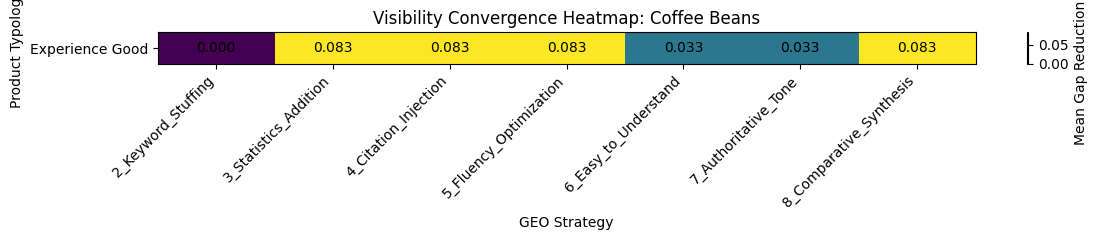

In [33]:
fig, ax = plt.subplots(figsize=(12, 2.5))

data = coffee_heatmap_matrix.values

im = ax.imshow(data, aspect="auto")

ax.set_xticks(np.arange(len(coffee_heatmap_matrix.columns)))
ax.set_yticks(np.arange(len(coffee_heatmap_matrix.index)))

ax.set_xticklabels(coffee_heatmap_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(coffee_heatmap_matrix.index)

ax.set_title("Visibility Convergence Heatmap: Coffee Beans")
ax.set_xlabel("GEO Strategy")
ax.set_ylabel("Product Typology")

for i in range(len(coffee_heatmap_matrix.index)):
    for j in range(len(coffee_heatmap_matrix.columns)):
        value = data[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.3f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Mean Gap Reduction in RRS")

plt.tight_layout()
plt.show()